<a href="https://colab.research.google.com/github/JSY929/3rd_orange/blob/main/04_TensorFlow_Keras_%EC%98%88%EC%A0%9C(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TensorFlow 설정하기

시작하려면 TensorFlow를 프로그램으로 가져옵니다.

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


[MNIST 데이터셋](https://www.kaggle.com/datasets/hojjatk/mnist-dataset)을 로드하여 준비합니다. 샘플 값을 정수에서 부동소수로 변환합니다:

참고: 자체 개발 환경을 사용하는 경우에 TensorFlow 2 패키지를 설치하려면 최신 `pip`로 업그레이드했는지 확인합니다. 자세한 내용은 [설치 가이드](https://www.tensorflow.org/install)를 참조합니다.

## 데이터세트 로드하기

[MNIST 데이터세트](https://www.kaggle.com/datasets/hojjatk/mnist-dataset)를 로드하고 준비합니다. 이미지의 픽셀 값 범위는 0-255입니다. 이때 값을 `255.0`으로 나누어 0-1 범위로 조정합니다. 그러면 샘플 데이터를 정수에서 부동 소수점 숫자로 변환합니다.

In [2]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# 데이터 확인
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(60000, 28, 28) (10000, 28, 28)
(60000,) (10000,)


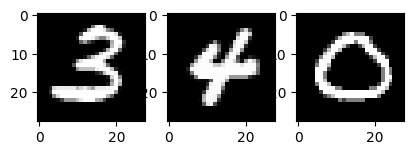

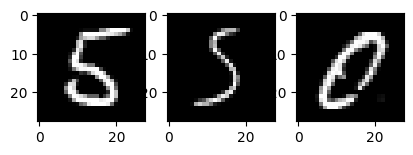

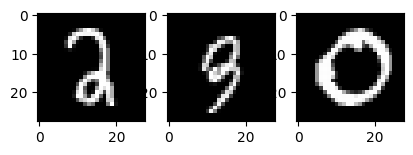

In [6]:
# 이미지 시작화
import matplotlib.pyplot as plt
import random
for i in range(1,4,1):
    for j in range(1,4,1):
        plt.subplot(i,4,j)
        plt.imshow(x_train[random.randint(0,60000)],cmap="gray")
    plt.show()

## 머신 러닝 모델 빌드하기

`tf.keras.Sequential` 모델을 빌드합니다.

In [7]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[`Sequential`](https://www.tensorflow.org/guide/keras/sequential_model)은 각 레이어에 하나의 입력 [텐서](https://www.tensorflow.org/guide/tensor?hl=ko)와 하나의 출력 텐서가 있는 레이어를 쌓는 데 유용합니다. 레이어는 다시 사용할 수 있고 훈련 가능한 변수를 포함하며 일반적인 수학적 구조를 가진 함수입니다. 대부분의 TensorFlow 모델은 레이어로 구성되어 있습니다. 이 모델은 [`Flatten`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten), [`Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense), [`Dropout`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) 레이어를 사용합니다.

각 예시에서 모델은 각 클래스에 대해 하나씩, [logits(분류 모델이 생성하는 원시 (정규화되지 않은) 예측 벡터)](https://developers.google.com/machine-learning/glossary#logits) 벡터를 반환합니다.

In [8]:
predictions = model(x_train[:1]).numpy()
predictions

array([[0.16705924, 0.07267299, 0.12298644, 0.0835392 , 0.04637458,
        0.05135978, 0.06854169, 0.07584088, 0.14114414, 0.17048115]],
      dtype=float32)

- x_train[:1] — 학습 데이터에서 첫 번째 이미지 한 장을 꺼냅니다. [0]이 아니라 [:1]을 쓴 이유는 배치 차원을 유지하기 위해서입니다. 즉 shape가 (28, 28)이 아니라 (1, 28, 28)이 됩니다. 모델은 항상 "여러 장 묶음(batch)"을 입력으로 기대하기 때문입니다.
- model(...) — 그 이미지를 모델에 통과시켜 출력 텐서를 얻습니다.
- .numpy() — 결과를 TensorFlow 텐서에서 다루기 쉬운 NumPy 배열로 변환합니다.

- 출력된 배열은 (1, 10) 모양이고, 안쪽의 값 10개는 숫자 0~9 각 클래스에 대한 점수
  - 인덱스 0이 "숫자 0일 가능성", 인덱스 1이 "숫자 1일 가능성"
- 가장 중요한 포인트는 값들이 전부 0.1 근처에 몰려 있다는 점임. 클래스가 10개이니 완전히 무작위라면 각 확률이 1/10 = 0.1이 되는데, 지금 값들(0.07 ~ 0.14)이 딱 그 근처인데 이는 모델이 아직 학습되지 않은(가중치가 무작위로 초기화된) 상태를 의미함
- 최댓값을 보면 인덱스 7(0.141)이 제일 높으니 "지금은 7이라고 추측"할 수 있지만 이건 의미 있는 예측이라기보다 초기화된 가중치의 우연한 결과에 가까움.
- 이후 model.fit(...)으로 학습을 마치고 나면, 실제 정답 숫자에 해당하는 인덱스의 값이 1에 가깝게 되는 것을 확인할 수 있음

`tf.nn.softmax` 함수는 다음과 같이 이러한 로짓을 각 클래스에 대한 *확률*로 변환합니다.

In [9]:
tf.nn.softmax(predictions).numpy()

array([[0.10683089, 0.09720876, 0.1022248 , 0.09827082, 0.09468565,
        0.09515886, 0.09680799, 0.0975172 , 0.10409792, 0.10719708]],
      dtype=float32)

`losses.SparseCategoricalCrossentropy`를 사용하여 훈련용 손실 함수를 정의합니다.

In [10]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

손실 함수는 실측 값의 벡터와 로짓의 벡터를 취하고 각 예시에 대한 스칼라 손실을 반환합니다. 이 손실은 참(true) 클래스의 음의 로그 확률과 같습니다. 모델이 올바른 클래스를 확신하는 경우 손실은 0입니다.

이 훈련되지 않은 모델은 무작위에 가까운 확률(각 클래스에 대해 1/10)을 제공하므로 초기 손실은 `-tf.math.log(1/10) ~= 2.3`에 근접해야 합니다.

손실 함수는 "모델의 예측이 정답에서 얼마나 벗어났는지"를 숫자 하나로 알려주는 채점기입니다. 입력으로 두 가지를 받습니다: 실제 정답(이 이미지는 숫자 5다)과 모델이 내놓은 점수들(로짓, 각 클래스에 대한 예측 점수). 그리고 예시 한 장마다 손실 점수(스칼라, 즉 숫자 하나)를 돌려줍니다. 점수가 클수록 많이 틀린 것, 0에 가까울수록 잘 맞힌 것입니다.
"참 클래스의 음의 로그 확률"이라는 말
이게 핵심인데, 계산 방식이 이렇습니다. 모델이 정답 클래스에 매긴 확률 하나만 꺼내서, 거기에 로그를 씌우고 마이너스를 붙입니다. 즉 손실 = −log(정답에 준 확률)입니다.
왜 이런 모양이냐면, 로그와 마이너스의 조합이 다음 성질을 갖기 때문입니다:

정답에 확률 1.0을 줬다면(완벽하게 확신) → −log(1) = 0. 손실이 0, 즉 "감점 없음". 이게 문장의 "올바른 클래스를 확신하면 손실은 0"이라는 부분입니다.
정답에 확률 0.5를 줬다면 → −log(0.5) ≈ 0.69. 어중간하니 어느 정도 감점.
정답에 확률 0.01처럼 아주 낮게 줬다면 → −log(0.01) ≈ 4.6. 정답을 거의 무시했으니 큰 감점.

정답 확률이 낮을수록 벌점이 가파르게 커지는 구조라, 모델이 "정답에 높은 확률을 주도록" 유도됩니다.
왜 처음엔 손실이 2.3쯤인가
앞에서 본 것처럼 학습 전 모델은 아직 아무것도 모르니, 10개 클래스에 확률을 거의 균등하게 1/10씩 뿌립니다. 그러면 정답 클래스에 준 확률도 대략 1/10입니다. 이걸 손실 공식에 넣으면:
−log(1/10) ≈ 2.3
그래서 "제대로 세팅됐다면 학습 첫 손실이 2.3 근처로 나와야 정상"이라는 뜻입니다. 이건 일종의 점검용 기준값(sanity check) 입니다. 만약 시작 손실이 2.3과 크게 다르다면(예: 10이나 0.1), 코드나 데이터 어딘가가 잘못됐을 가능성을 의심해볼 수 있습니다.
참고로 -tf.math.log(1/10)에서 로그는 자연로그(밑이 e)입니다. 계산하면 log(10) ≈ 2.302… 이라서 2.3이 나옵니다.

In [11]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.3522077)

훈련을 시작하기 전에 Keras `Model.compile`을 사용하여 모델을 구성하고 컴파일합니다. [`optimizer`](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers) 클래스를 `adam`으로 설정하고 `loss`를 앞에서 정의한 `loss_fn` 함수로 설정합니다. `metrics` 매개변수를 `accuracy`로 설정하여 모델에 대해 평가할 메트릭을 지정합니다.

In [ ]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

## 모델 훈련 및 평가하기

모델을 훈련하고 평가합니다:

In [ ]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9135 - loss: 0.2974
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9577 - loss: 0.1418
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9684 - loss: 0.1058
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9726 - loss: 0.0873
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9764 - loss: 0.0744


`Model.evaluate` 메서드는 일반적으로 [검증 세트](https://developers.google.com/machine-learning/glossary#validation-set) 또는 [테스트 세트](https://developers.google.com/machine-learning/glossary#test-set)에서 모델의 성능을 확인합니다.

In [ ]:
model.evaluate(x_test,  y_test, verbose=2)

313/313 - 2s - 5ms/step - accuracy: 0.9765 - loss: 0.0771


[0.0771290734410286, 0.9764999747276306]

훈련된 이미지 분류기는 이 데이터셋에서 약 98%의 정확도를 달성합니다. 더 자세한 내용은 [TensorFlow 튜토리얼](https://www.tensorflow.org/tutorials?hl=ko)을 참고하세요.

모델이 확률을 반환하도록 하려면 다음과 같이 훈련된 모델을 래핑하고 여기에 소프트맥스를 첨부할 수 있습니다.

In [ ]:
probability_model = tf.keras.Sequential([
  model,                        # 학습된 기존 모델 (로짓을 출력)
  tf.keras.layers.Softmax()     # 그 뒤에 softmax 층을 하나 더 붙임
])

테스트 데이터에서 이미지 5장을 꺼내 이 확률 모델에 통과시킵니다. 결과는 shape=(5, 10), 즉 5장 각각에 대해 10개(숫자 0~9) 클래스의 확률이 나옵니다.

In [ ]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[0.08533767, 0.08533766, 0.08533791, 0.08534334, 0.08533766,
        0.08533767, 0.08533766, 0.23195474, 0.08533768, 0.08533798],
       [0.08534309, 0.08537317, 0.23186895, 0.0853559 , 0.08534309,
        0.08534327, 0.08534315, 0.08534309, 0.08534319, 0.08534309],
       [0.0853633 , 0.23154892, 0.08540121, 0.08536904, 0.08536974,
        0.08536489, 0.08536515, 0.08542237, 0.08543172, 0.08536371],
       [0.23195474, 0.08533767, 0.08534222, 0.08533768, 0.08533779,
        0.08533774, 0.08533853, 0.08533796, 0.08533767, 0.08533807],
       [0.08538317, 0.08537907, 0.08537983, 0.08537907, 0.23129837,
        0.08537908, 0.08537988, 0.08539993, 0.08537914, 0.0856425 ]],
      dtype=float32)>

각 행이 이미지 한 장의 예측이고, 10개 값을 더하면 1이 됩니다. 핵심은 각 행에서 유독 하나만 튀는 값(0.23) 이 있고 나머지는 모두 0.085 언저리라는 점입니다. 0.23이 위치한 인덱스가 모델이 "이 숫자다"라고 지목한 답입니다:

1행: 인덱스 7이 0.23 → 7로 예측
2행: 인덱스 2가 0.23 → 2로 예측
3행: 인덱스 1이 0.23 → 1로 예측
4행: 인덱스 0이 0.23 → 0으로 예측
5행: 인덱스 4가 0.23 → 4로 예측

이 순서(7, 2, 1, 0, 4)는 MNIST 테스트셋 앞 5장의 실제 정답과 일치합니다. 즉 학습이 잘 됐다는 뜻입니다.